In [27]:
from pathlib import Path

import pandas as pd
from torch import tensor
import matplotlib.pyplot as plt

import re

DIRECTORY = Path(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file')
DATA_PATH = DIRECTORY / 'final_logger_data' / 'original' / 'filtered_data'

In [28]:
half_q_filter = DATA_PATH / r'Vistral-7B-Chat+domain_masked_wrong_answer.csv'
wrong_ans_filter =  r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\domain_mmlu_data\filtered_data\vistral_7b_mini_logging_file_domain.csv'

In [29]:
wrong_df = pd.read_csv(wrong_ans_filter)
wrong_df.rename(columns={'score': 'wrong_score', 'retained':'wrong_retained'}, inplace=True)
# wrong_df.drop(columns=['rouge_score'], inplace=True)
wrong_df

,predict,label,wrong_score,wrong_retained
0,Can ngăn A và giúp B.,Cùng với A đánh B cho vui.,0.307692,True
1,Gọi điện cho gia đình của em đó và nhờ sự giúp...,Đèo em bé đó đến gặp công an.,0.166667,True
2,Không trung thực.,Không tôn trọng lẽ phải.,0.250000,True
3,"Làm giàu bằng chính sức lực, tài năng của mình",Nhiệt tình giúp đỡ mọi người mà không tính toá...,0.000000,True
4,Chính trực.,Khiêm tốn.,0.000000,True
...,...,...,...,...
2102,Số lượng cá thể trong quần xã.,Số lượng loài trong quần thể.,0.615385,False
2103,Cá voi.,Rùa núi vàng.,0.000000,True
2104,Da có tuyến nhờn.,Da có lớp vảy sừng bao bọc.,0.363636,True
2105,Do các loại dịch bệnh bất thường.,Do các loại thiên tai xảy ra.,0.428571,True


In [30]:
half_df = pd.read_csv(half_q_filter)
half_retained = half_df['retained']
half_retained = half_retained.to_list()

In [31]:
question_df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\data_done\domain.csv')
question_df

,Question,A,B,C,D,Answer
0,"Trong giờ ra chơi, A trêu đùa và đánh B gây ch...",Báo với cô giáo chủ nhiệm để tìm cách giải quyết.,Mặc kệ vì không liên quan đến mình.,Cùng với A đánh B cho vui.,Chạy đi chỗ khác chơi.,A
1,Trên đường đi học về em nhìn thấy một thanh ni...,Lờ đi chỗ khác và coi như không biết.,"Nhờ sự giúp đỡ của người lớn, đưa em bé đó đến...",Đèo em bé đó đến gặp công an.,Đạp thật nhanh về nhà.,B
2,Câu thành ngữ: Gió chiều nào theo chiều ấy nói...,Không tôn trọng lẽ phải.,Không trung thực.,Không chín chắn.,Không có ý thức.,C
3,Em rèn tính liêm khiết trong học tập là:,Nhiệt tình giúp đỡ mọi người mà không tính toá...,"Làm giàu bằng chính sức lực, tài năng của mình",Nhặt được của rơi trả lại cho người bị mất,Tất cả đáp án trên,D
4,"Không hám danh, hám lợi, không nhỏ nhen, ích k...",Liêm khiết.,Công bằng.,Lẽ phải.,Khiêm tốn.,A
...,...,...,...,...,...,...
2102,Tiêu chí nào dưới đây biểu thị sự đa dạng sinh...,Số lượng loài trong quần thể.,Số lượng cá thể trong quần xã.,Số lượng loài.,Số lượng cá thể trong một loài.,C
2103,Động vật nào dưới đây thụ tinh ngoài?,Cá chép.,Chim bồ câu.,Rùa núi vàng.,Thỏ hoang.,A
2104,Đặc điểm nào dưới đâu giúp cơ thể thằn lằn giữ...,Da có lớp vảy sừng bao bọc.,Mắt có tuyến lệ giữ ẩm.,Hậu thận và trực tràng có khả năng hấp thụ lại...,Cả A và C đều đúng.,D
2105,"Trong các nguyên nhân sau, đâu là nguyên nhân ...",Do các hoạt động của con người.,Do các loại thiên tai xảy ra.,Do khả năng thích nghi của sinh vật bị suy giả...,Do các loại dịch bệnh bất thường.,A


In [32]:
grade_df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\domain_masked_wrong_answer.csv')
grade = grade_df['Grade']
grade

0       GDCD 8
1       GDCD 8
2       GDCD 8
3       GDCD 8
4       GDCD 8
         ...  
2102    Sinh 7
2103    Sinh 7
2104    Sinh 7
2105    Sinh 7
2106    Sinh 7
Name: Grade, Length: 2107, dtype: object

In [33]:
question = question_df['Question'].apply(lambda x : len(x.split()) > 8).to_list()
question

[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 False,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 Tr

In [34]:
idx = 0
half_retained_recovered = []

for x in question:
    if x:
        half_retained_recovered.append(half_retained[idx])
        idx += 1
    else:
        half_retained_recovered.append(True)
len(half_retained_recovered)


2107

In [35]:
half_retained_recovered = pd.DataFrame(half_retained_recovered, columns=['half_retained'])
half_retained_recovered

,half_retained
0,True
1,True
2,True
3,True
4,True
...,...
2102,True
2103,True
2104,True
2105,True


In [36]:
df = pd.concat([wrong_df, half_retained_recovered, grade], axis=1)
df

,predict,label,wrong_score,wrong_retained,half_retained,Grade
0,Can ngăn A và giúp B.,Cùng với A đánh B cho vui.,0.307692,True,True,GDCD 8
1,Gọi điện cho gia đình của em đó và nhờ sự giúp...,Đèo em bé đó đến gặp công an.,0.166667,True,True,GDCD 8
2,Không trung thực.,Không tôn trọng lẽ phải.,0.250000,True,True,GDCD 8
3,"Làm giàu bằng chính sức lực, tài năng của mình",Nhiệt tình giúp đỡ mọi người mà không tính toá...,0.000000,True,True,GDCD 8
4,Chính trực.,Khiêm tốn.,0.000000,True,True,GDCD 8
...,...,...,...,...,...,...
2102,Số lượng cá thể trong quần xã.,Số lượng loài trong quần thể.,0.615385,False,True,Sinh 7
2103,Cá voi.,Rùa núi vàng.,0.000000,True,True,Sinh 7
2104,Da có tuyến nhờn.,Da có lớp vảy sừng bao bọc.,0.363636,True,True,Sinh 7
2105,Do các loại dịch bệnh bất thường.,Do các loại thiên tai xảy ra.,0.428571,True,True,Sinh 7


In [37]:
cond = (df['half_retained'] == True) & (df['wrong_retained'] == True)
df['retained'] = cond

In [38]:
df[df['retained'] == True]

,predict,label,wrong_score,wrong_retained,half_retained,Grade,retained
0,Can ngăn A và giúp B.,Cùng với A đánh B cho vui.,0.307692,True,True,GDCD 8,True
1,Gọi điện cho gia đình của em đó và nhờ sự giúp...,Đèo em bé đó đến gặp công an.,0.166667,True,True,GDCD 8,True
2,Không trung thực.,Không tôn trọng lẽ phải.,0.250000,True,True,GDCD 8,True
3,"Làm giàu bằng chính sức lực, tài năng của mình",Nhiệt tình giúp đỡ mọi người mà không tính toá...,0.000000,True,True,GDCD 8,True
4,Chính trực.,Khiêm tốn.,0.000000,True,True,GDCD 8,True
...,...,...,...,...,...,...,...
2100,Thỏ không có tuyến vú.,Ăn thức ăn bằng cách gặm nhấm.,0.000000,True,True,Sinh 7,True
2101,Nhện.,Ốc sên.,0.000000,True,True,Sinh 7,True
2103,Cá voi.,Rùa núi vàng.,0.000000,True,True,Sinh 7,True
2104,Da có tuyến nhờn.,Da có lớp vảy sừng bao bọc.,0.363636,True,True,Sinh 7,True


In [39]:
df.to_csv(DIRECTORY / 'original_filtered.csv', index=False)

In [40]:
def plot_dropped(df):
    fig, ax = plt.subplots(figsize = (60, 20))

    count = {}
    count_drop = {}
    for key in df['Grade'].unique():
        count[key] = [df[df['Grade'] == key].shape[0]]
        count_drop[key] = [df[(df['Grade'] == key) & (df['retained'] == False)].shape[0]]

    for grade, value in count.items():
        p = ax.bar(grade, value[0], color = 'b')
        ax.bar_label(p, label_type = 'edge')

    for grade, value in count_drop.items():
        p = ax.bar(grade, value[0], color = 'r')
        ax.bar_label(p, label_type = 'edge')

    # plt.title(f'{name}')
    # if drop_math:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}_no_math.png')
    # else:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}.png')
    plt.close()
    return fig

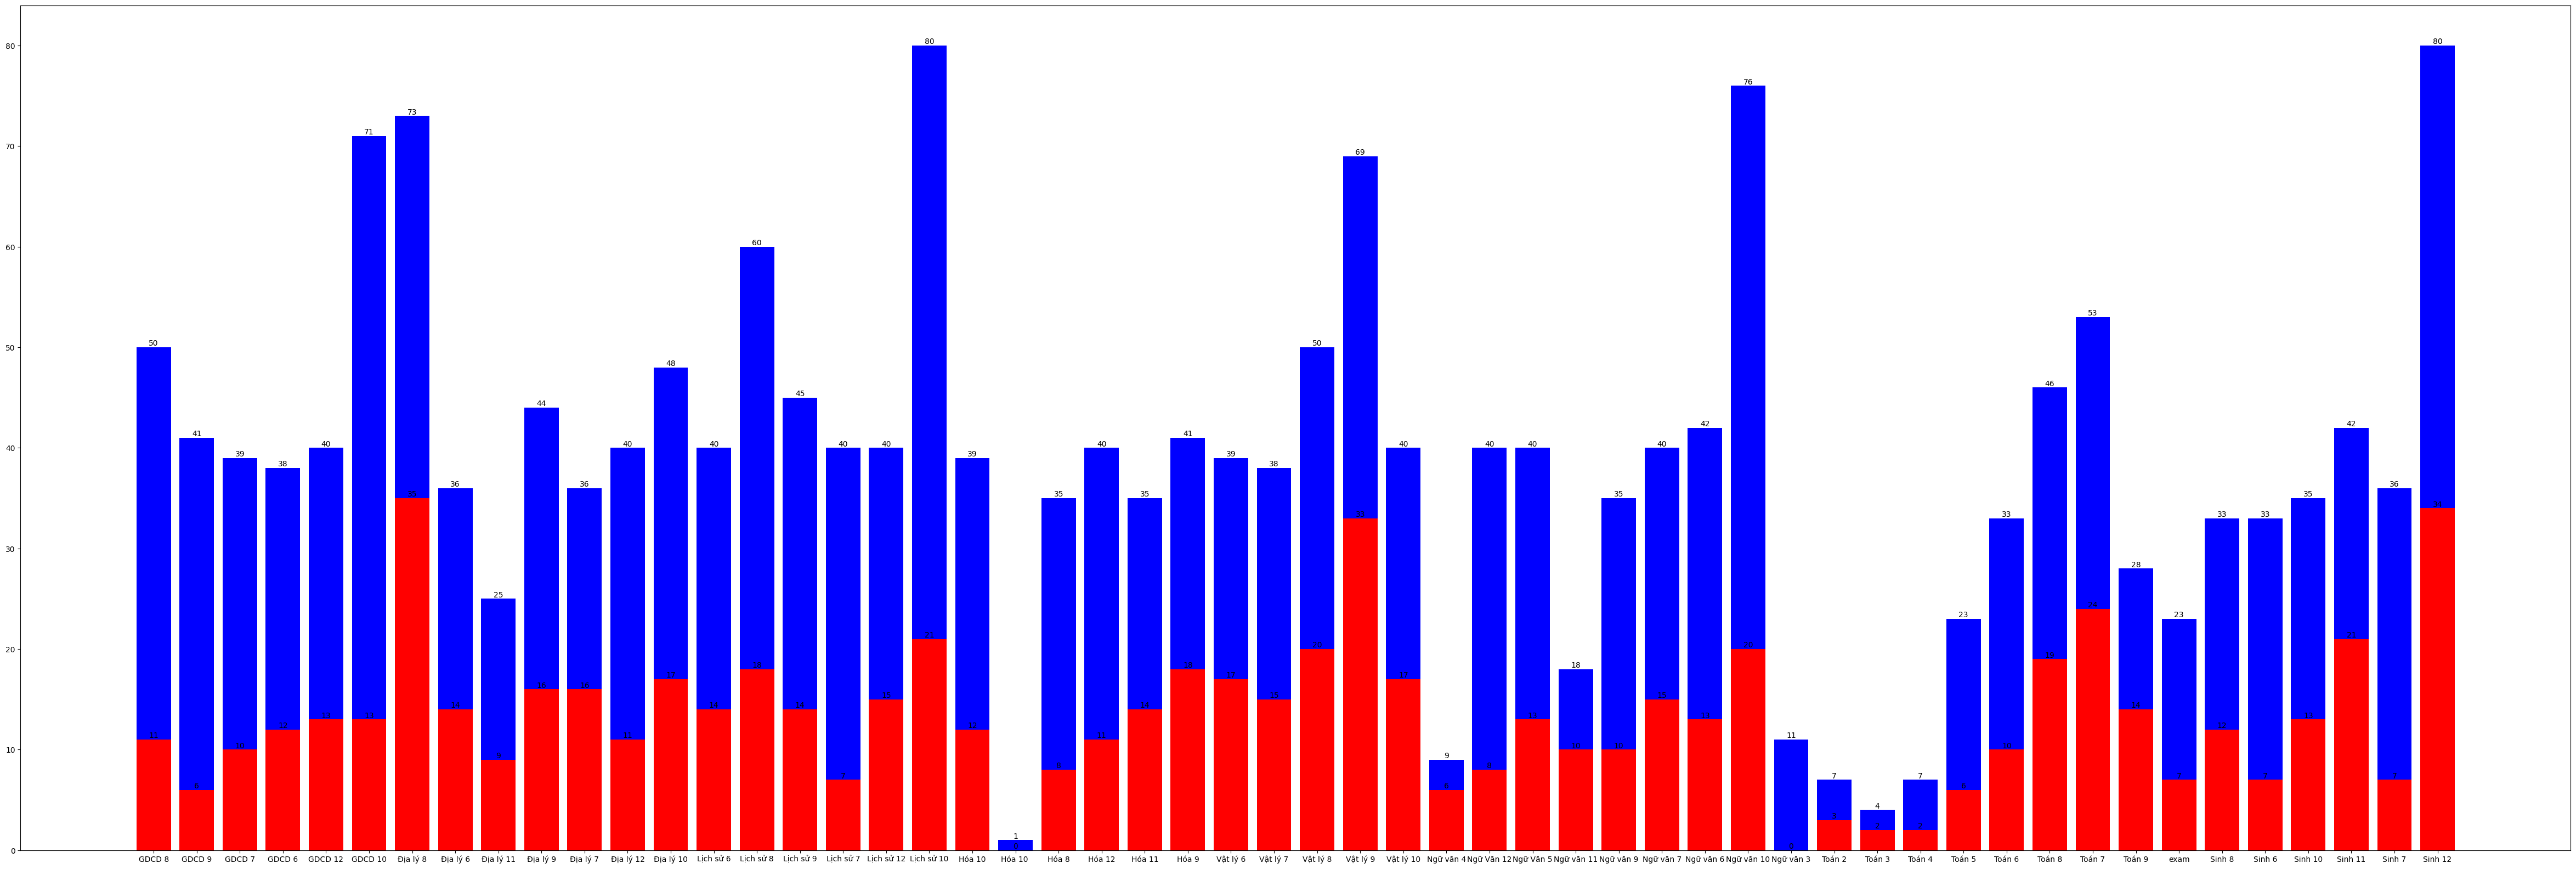

In [41]:
plot_dropped(df)

In [43]:
df['retained'].value_counts()

retained
True     1394
False     713
Name: count, dtype: int64